In [65]:
import pandas as pd
import pyhere as here
import numpy as np
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# regular expressions lib
import re

In [2]:
here.here()

PosixPath('/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction')

In [4]:
# pyhere automatically finds the .here marker
csv_path = here.here("data", "raghadalharbi","METABRIC_RNA_Mutation.csv")
df = pd.read_csv(csv_path)

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_17232/1859274059.py:3: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


In [5]:
df.shape

(1904, 693)

In [7]:
df

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,7295,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1900,7296,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1901,7297,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1902,7298,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)

In [10]:
df.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,overall_survival,radio_therapy,tumor_size,tumor_stage,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,stk11,bard1,mlh1,msh2,msh6,pms2,epcam,rad51c,rad51d,rad50,rb1,rbl1,rbl2,ccna1,ccnb1,cdk1,ccne1,cdk2,cdc25a,ccnd1,cdk4,cdk6,ccnd2,cdkn2a,cdkn2b,myc,cdkn1a,cdkn1b,e2f1,e2f2,e2f3,e2f4,e2f5,e2f6,e2f7,e2f8,src,jak1,jak2,stat1,stat2,stat3,stat5a,stat5b,mdm2,tp53bp1,adam10,adam17,aph1a,aph1b,arrdc1,cir1,ctbp1,ctbp2,cul1,dll1,dll3,dll4,dtx1,dtx2,dtx3,dtx4,ep300,fbxw7,hdac1,hdac2,hes1,hes5,heyl,itch,jag1,jag2,kdm5a,lfng,maml1,maml2,maml3,ncor2,ncstn,notch1,notch2,notch3,nrarp,numb,numbl,psen1,psen2,psenen,rbpj,rbpjl,rfng,snw1,spen,hes2,hes4,hes7,hey1,hey2,acvr1,acvr1b,acvr1c,acvr2a,acvr2b,acvrl1,akt1,akt1s1,akt2,apaf1,arl11,atr,aurka,bad,bcl2,bcl2l1,bmp10,bmp15,bmp2,bmp3,bmp4,bmp5,bmp6,bmp7,bmpr1a,bmpr1b,bmpr2,braf,casp10,casp3,casp6,casp7,casp8,casp9,chek1,csf1,csf1r,cxcl8,cxcr1,cxcr2,dab2,diras3,dlec1,dph1,egfr,eif4e,eif4ebp1,eif5a2,erbb2,erbb3,erbb4,fas,fgf1,fgfr1,folr1,folr2,folr3,foxo1,foxo3,gdf11,gdf2,gsk3b,hif1a,hla-g,hras,igf1,igf1r,inha,inhba,inhbc,itgav,itgb3,izumo1r,kdr,kit,kras,map2k1,map2k2,map2k3,map2k4,map2k5,map3k1,map3k3,map3k4,map3k5,mapk1,mapk12,mapk14,mapk3,mapk4,mapk6,mapk7,mapk8,mapk9,mdc1,mlst8,mmp1,mmp10,mmp11,mmp12,mmp13,mmp14,mmp15,mmp16,mmp17,mmp19,mmp2,mmp21,mmp23b,mmp24,mmp25,mmp26,mmp27,mmp28,mmp3,mmp7,mmp9,mtor,nfkb1,nfkb2,opcml,pdgfa,pdgfb,pdgfra,pdgfrb,pdpk1,peg3,pik3ca,pik3r1,pik3r2,plagl1,ptk2,rab25,rad51,raf1,rassf1,rheb,rictor,rps6,rps6ka1,rps6ka2,rps6kb1,rps6kb2,rptor,slc19a1,smad1,smad2,smad3,smad4,smad5,smad6,smad7,smad9,sptbn1,terc,tert,tgfb1,tgfb2,tgfb3,tgfbr1,tgfbr2,tgfbr3,tsc1,tsc2,vegfa,vegfb,wfdc2,wwox,zfyve9,arid1a,arid1b,cbfb,gata3,kmt2c,kmt2d,myh9,ncor1,pde4dip,ptprd,ros1,runx1,tbx3,abcb1,abcb11,abcc1,abcc10,bbc3,bmf,cyp2c8,cyp3a4,fgf2,fn1,map2,map4,mapt,nr1i2,slco1b3,tubb1,tubb4a,tubb4b,twist1,adgra2,afdn,aff2,agmo,agtr2,ahnak,ahnak2,akap9,alk,apc,arid2,arid5b,asxl1,asxl2,bap1,bcas3,birc6,cacna2d3,ccnd3,chd1,clk3,clrn2,col12a1,col22a1,col6a3,ctcf,ctnna1,ctnna3,dnah11,dnah2,dnah5,dtwd2,fam20c,fanca,fancd2,flt3,foxp1,frmd3,gh1,gldc,gpr32,gps2,hdac9,herc2,hist1h2bc,kdm3a,kdm6a,klrg1,l1cam,lama2,lamb3,large1,ldlrap1,lifr,lipi,magea8,map3k10,map3k13,men1,mtap,muc16,myo1a,myo3a,ncoa3,nek1,nf2,npnt,nr2f1,nr3c1,nras,nrg3,nt5e,or6a2,palld,pbrm1,ppp2cb,ppp2r2a,prkacg,prkce,prkcq,prkcz,prkg1,prps2,prr16,ptpn22,ptprm,rasgef1b,rpgr,ryr2,sbno1,setd1a,setd2,setdb1,sf3b1,sgcd,shank2,siah1,sik1,sik2,smarcb1,smarcc1,smarcc2,smarcd1,spaca1,stab2,stmn2,syne1,taf1,taf4b,tbl1xr1,tg,thada,thsd7a,ttyh1,ubr5,ush2a,usp9x,utrn,zfp36l1,ackr3,akr1c1,akr1c2,akr1c3,akr1c4,akt3,ar,bche,cdk8,cdkn2c,cyb5a,cyp11a1,cyp11b2,cyp17a1,cyp19a1,cyp21a2,cyp3a43,cyp3a5,cyp3a7,ddc,hes6,hsd17b1,hsd17b10,hsd17b11,hsd17b12,hsd17b13,hsd17b14,hsd17b2,hsd17b3,hsd17b4,hsd17b6,hsd17b7,hsd17b8,hsd3b1,hsd3b2,hsd3b7,mecom,met,ncoa2,nrip1,pik3r3,prkci,prkd1,ran,rdh5,sdc4,serpini1,shbg,slc29a1,sox9,spry2,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,1904.000000,1904.000000,1884.000000,1403.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1904.000000,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.9

In [11]:
df

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,stk11,bard1,mlh1,msh2,msh6,pms2,epcam,rad51c,rad51d,rad50,rb1,rbl1,rbl2,ccna1,ccnb1,cdk1,ccne1,cdk2,cdc25a,ccnd1,cdk4,cdk6,ccnd2,cdkn2a,cdkn2b,myc,cdkn1a,cdkn1b,e2f1,e2f2,e2f3,e2f4,e2f5,e2f6,e2f7,e2f8,src,jak1,jak2,stat1,stat2,stat3,stat5a,stat5b,mdm2,tp53bp1,adam10,adam17,aph1a,aph1b,arrdc1,cir1,ctbp1,ctbp2,cul1,dll1,dll3,dll4,dtx1,dtx2,dtx3,dtx4,ep300,fbxw7,hdac1,hdac2,hes1,hes5,heyl,itch,jag1,jag2,kdm5a,lfng,maml1,maml2,maml3,ncor2,ncstn,notch1,notch2,notch3,nrarp,numb,numbl,psen1,psen2,psenen,rbpj,rbpjl,rfng,snw1,spen,hes2,hes4,hes7,hey1,hey2,acvr1,acvr1b,acvr1c,acvr2a,acvr2b,acvrl1,akt1,akt1s1,akt2,apaf1,arl11,atr,aurka,bad,bcl2,bcl2l1,bmp10,bmp15,bmp2,bmp3,bmp4,bmp5,bmp6,bmp7,bmpr1a,bmpr1b,bmpr2,braf,casp10,casp3,casp6,casp7,casp8,casp9,chek1,csf1,csf1r,cxcl8,cxcr1,cxcr2,dab2,diras3,dlec1,dph1,egfr,eif4e,eif4ebp1,eif5a2,erbb2,erbb3,erbb4,fas,fgf1,fgfr1,folr1,folr2,folr3,foxo1,foxo3,gdf11,gdf2,gsk3b,hif1a,hla-g,hras,igf1,igf1r,inha,inhba,inhbc,itgav,itgb3,izumo1r,kdr,kit,kras,map2k1,map2k2,map2k3,map2k4,map2k5,map3k1,map3k3,map3k4,map3k5,mapk1,mapk12,mapk14,mapk3,mapk4,mapk6,mapk7,mapk8,mapk9,mdc1,mlst8,mmp1,mmp10,mmp11,mmp12,mmp13,mmp14,mmp15,mmp16,mmp17,mmp19,mmp2,mmp21,mmp23b,mmp24,mmp25,mmp26,mmp27,mmp28,mmp3,mmp7,mmp9,mtor,nfkb1,nfkb2,opcml,pdgfa,pdgfb,pdgfra,pdgfrb,pdpk1,peg3,pik3ca,pik3r1,pik3r2,plagl1,ptk2,rab25,rad51,raf1,rassf1,rheb,rictor,rps6,rps6ka1,rps6ka2,rps6kb1,rps6kb2,rptor,slc19a1,smad1,smad2,smad3,smad4,smad5,smad6,smad7,smad9,sptbn1,terc,tert,tgfb1,tgfb2,tgfb3,tgfbr1,tgfbr2,tgfbr3,tsc1,tsc2,vegfa,vegfb,wfdc2,wwox,zfyve9,arid1a,arid1b,cbfb,gata3,kmt2c,kmt2d,myh9,ncor1,pde4dip,ptprd,ros1,runx1,tbx3,abcb1,abcb11,abcc1,abcc10,bbc3,bmf,cyp2c8,cyp3a4,fgf2,fn1,map2,map4,mapt,nr1i2,slco1b3,tubb1,tubb4a,tubb4b,twist1,adgra2,afdn,aff2,agmo,agtr2,ahnak,ahnak2,akap9,alk,apc,arid2,arid5b,asxl1,asxl2,bap1,bcas3,birc6,cacna2d3,ccnd3,chd1,clk3,clrn2,col12a1,col22a1,col6a3,ctcf,ctnna1,ctnna3,dnah11,dnah2,dnah5,dtwd2,fam20c,fanca,fancd2,flt3,foxp1,frmd3,gh1,gldc,gpr32,gps2,hdac9,herc2,hist1h2bc,kdm3a,kdm6a,klrg1,l1cam,lama2,lamb3,large1,ldlrap1,lifr,lipi,magea8,map3k10,map3k13,men1,mtap,muc16,myo1a,myo3a,ncoa3,nek1,nf2,npnt,nr2f1,nr3c1,nras,nrg3,nt5e,or6a2,palld,pbrm1,ppp2cb,ppp2r2a,prkacg,prkce,prkcq,prkcz,prkg1,prps2,prr16,ptpn22,ptprm,rasgef1b,rpgr,ryr2,sbno1,setd1a,setd2,setdb1,sf3b1,sgcd,shank2,siah1,sik1,sik2,smarcb1,smarcc1,smarcc2,smarcd1,spaca1,stab2,stmn2,syne1,taf1,taf4b,tbl1xr1,tg,thada,thsd7a,ttyh1,ubr5,ush2a,usp9x,utrn,zfp36l1,ackr3,akr1c1,akr1c2,akr1c3,akr1c4,akt3,ar,bche,cdk8,cdkn2c,cyb5a,cyp11a1,cyp11b2,cyp17a1,cyp19a1,cyp21a2,cyp3a43,cyp3a5,cyp3a7,ddc,hes6,hsd17b1,hsd17b10,hsd17b11,hsd17b12,hsd17b13,hsd17b14,hsd17b2,hsd17b3,hsd17b4,hsd17b6,hsd17b7,hsd17b8,hsd3b1,hsd3b2,hsd3b7,mecom,met,ncoa2,nrip1,pik3r3,prkci,prkd1,ran,rdh5,sdc4,serpini1,shbg,slc29a1,sox9,spry2,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,cdh1_mut,dnah2_mut,kmt2d_mut,ush2a_mut,ryr2_mut,dnah5_mut,herc2_mut,pde4dip_mut,akap9_mut,tg_mut,birc6_mut,utrn_mut,tbx3_mut,col6a3_mut,arid1a_mut,lama2_mut,notch1_mut,cbfb_mut,ncor2_mut,col12a1_mut,col22a1_mut,pten_mut,akt1_mut,atr_mut,thada_mut,ncor1_mut,stab2_mut,myh9_mut,runx1_mut,nf1_mut,map2k4_mut,ros1_mut,lamb3_mut,arid1b_mut,erbb2_mut,sf3b1_mut,sha

In [12]:
# get a feel for the dataset
clinical_cols = [c for c in df.columns if "stage" in c.lower() or "grade" in c.lower() or "status" in c.lower()]
survival_cols = [c for c in df.columns if "surv" in c.lower() or "event" in c.lower() or "time" in c.lower()]
expr_cols = [c for c in df.columns if c.isupper() and len(c) < 10]  # heuristic: gene names

In [13]:
print("Clinical:", len(clinical_cols))
print("Survival:", len(survival_cols))
print("Gene expression:", len(expr_cols))

Clinical: 7
Survival: 2
Gene expression: 0


In [15]:
clinical_cols

['er_status_measured_by_ihc',
 'er_status',
 'neoplasm_histologic_grade',
 'her2_status_measured_by_snp6',
 'her2_status',
 'pr_status',
 'tumor_stage']

In [19]:
df[clinical_cols]

,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,pr_status,tumor_stage
0,Positve,Positive,3.0,NEUTRAL,Negative,Negative,2.0
1,Positve,Positive,3.0,NEUTRAL,Negative,Positive,1.0
2,Positve,Positive,2.0,NEUTRAL,Negative,Positive,2.0
3,Positve,Positive,2.0,NEUTRAL,Negative,Positive,2.0
4,Positve,Positive,3.0,NEUTRAL,Negative,Positive,2.0
...,...,...,...,...,...,...,...
1899,Positve,Positive,3.0,NEUTRAL,Negative,Positive,NaN
1900,Positve,Positive,3.0,GAIN,Positive,Negative,NaN
1901,Positve,Positive,3.0,NEUTRAL,Negative,Positive,NaN
1902,Positve,Positive,2.0,NEUTRAL,Negative,Positive,NaN


In [18]:
df[survival_cols]

,overall_survival_months,overall_survival
0,140.500000,1
1,84.633333,1
2,163.700000,0
3,164.933333,1
4,41.366667,0
...,...,...
1899,196.866667,1
1900,44.733333,0
1901,175.966667,0
1902,86.233333,0


In [20]:
for col in clinical_cols[:10]:  
    print(col, df[col].unique()[:10])


er_status_measured_by_ihc ['Positve' 'Negative' nan]
er_status ['Positive' 'Negative']
neoplasm_histologic_grade [ 3.  2.  1. nan]
her2_status_measured_by_snp6 ['NEUTRAL' 'LOSS' 'GAIN' 'UNDEF']
her2_status ['Negative' 'Positive']
pr_status ['Negative' 'Positive']
tumor_stage [ 2.  1.  4.  3. nan  0.]


In [28]:
df["3-gene_classifier_subtype"].unique()

array(['ER-/HER2-', 'ER+/HER2- High Prolif', nan, 'ER+/HER2- Low Prolif',
       'HER2+'], dtype=object)

In [40]:
df["3-gene_classifier_subtype"] = df["3-gene_classifier_subtype"].fillna("unknown")

In [41]:
# Create a Kaplan-Meier fitter instance

time = df["overall_survival_months"]
event = df["overall_survival"]

group = df["3-gene_classifier_subtype"]

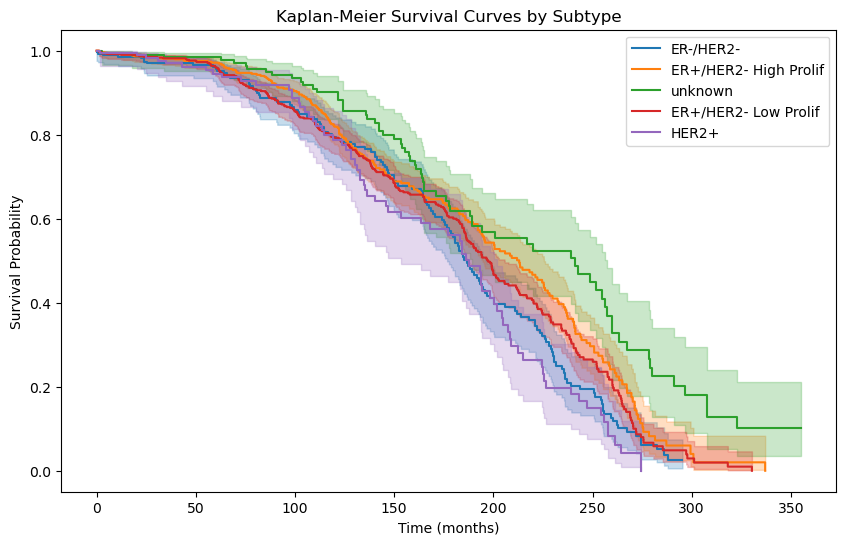

In [42]:
# Create KM model
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for subtype in group.unique():
    mask = group == subtype
    kmf.fit(time[mask], event[mask], label=subtype)
    kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curves by Subtype")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.show()

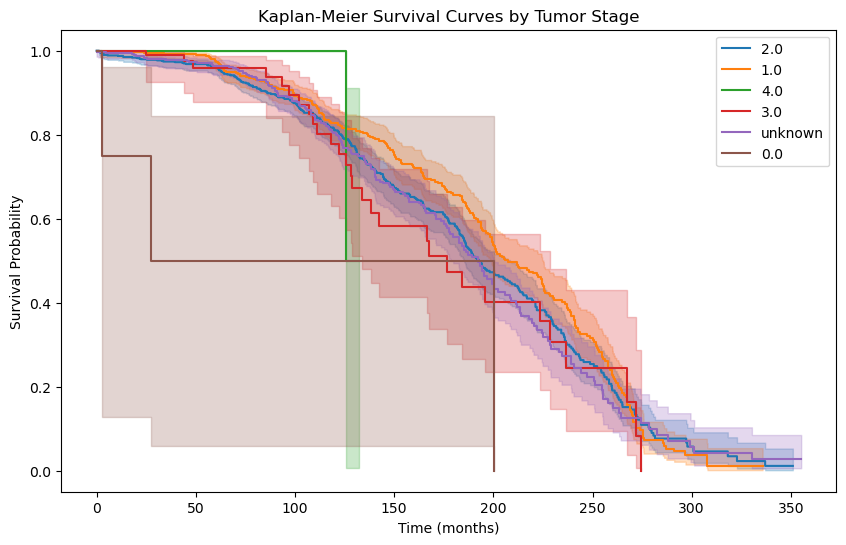

In [44]:
# Create KM model
df["tumor_stage"] = df["tumor_stage"].fillna("unknown")
group = df["tumor_stage"]

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for subtype in group.unique():
    mask = group == subtype
    kmf.fit(time[mask], event[mask], label=subtype)
    kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curves by Tumor Stage")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.show()

## Split data into clinical metadata, gene expression, and mutation csvs for easier use

In [45]:
list(df.columns)

['patient_id',
 'age_at_diagnosis',
 'type_of_breast_surgery',
 'cancer_type',
 'cancer_type_detailed',
 'cellularity',
 'chemotherapy',
 'pam50_+_claudin-low_subtype',
 'cohort',
 'er_status_measured_by_ihc',
 'er_status',
 'neoplasm_histologic_grade',
 'her2_status_measured_by_snp6',
 'her2_status',
 'tumor_other_histologic_subtype',
 'hormone_therapy',
 'inferred_menopausal_state',
 'integrative_cluster',
 'primary_tumor_laterality',
 'lymph_nodes_examined_positive',
 'mutation_count',
 'nottingham_prognostic_index',
 'oncotree_code',
 'overall_survival_months',
 'overall_survival',
 'pr_status',
 'radio_therapy',
 '3-gene_classifier_subtype',
 'tumor_size',
 'tumor_stage',
 'death_from_cancer',
 'brca1',
 'brca2',
 'palb2',
 'pten',
 'tp53',
 'atm',
 'cdh1',
 'chek2',
 'nbn',
 'nf1',
 'stk11',
 'bard1',
 'mlh1',
 'msh2',
 'msh6',
 'pms2',
 'epcam',
 'rad51c',
 'rad51d',
 'rad50',
 'rb1',
 'rbl1',
 'rbl2',
 'ccna1',
 'ccnb1',
 'cdk1',
 'ccne1',
 'cdk2',
 'cdc25a',
 'ccnd1',
 'cdk4',

In [46]:
# mutation columns
mutation_cols = [c for c in df.columns if c.endswith("_mut")]


In [53]:
# mutation information
mutation_cols

['pik3ca_mut',
 'tp53_mut',
 'muc16_mut',
 'ahnak2_mut',
 'kmt2c_mut',
 'syne1_mut',
 'gata3_mut',
 'map3k1_mut',
 'ahnak_mut',
 'dnah11_mut',
 'cdh1_mut',
 'dnah2_mut',
 'kmt2d_mut',
 'ush2a_mut',
 'ryr2_mut',
 'dnah5_mut',
 'herc2_mut',
 'pde4dip_mut',
 'akap9_mut',
 'tg_mut',
 'birc6_mut',
 'utrn_mut',
 'tbx3_mut',
 'col6a3_mut',
 'arid1a_mut',
 'lama2_mut',
 'notch1_mut',
 'cbfb_mut',
 'ncor2_mut',
 'col12a1_mut',
 'col22a1_mut',
 'pten_mut',
 'akt1_mut',
 'atr_mut',
 'thada_mut',
 'ncor1_mut',
 'stab2_mut',
 'myh9_mut',
 'runx1_mut',
 'nf1_mut',
 'map2k4_mut',
 'ros1_mut',
 'lamb3_mut',
 'arid1b_mut',
 'erbb2_mut',
 'sf3b1_mut',
 'shank2_mut',
 'ep300_mut',
 'ptprd_mut',
 'usp9x_mut',
 'setd2_mut',
 'setd1a_mut',
 'thsd7a_mut',
 'afdn_mut',
 'erbb3_mut',
 'rb1_mut',
 'myo1a_mut',
 'alk_mut',
 'fanca_mut',
 'adgra2_mut',
 'ubr5_mut',
 'pik3r1_mut',
 'myo3a_mut',
 'asxl2_mut',
 'apc_mut',
 'ctcf_mut',
 'asxl1_mut',
 'fancd2_mut',
 'taf1_mut',
 'kdm6a_mut',
 'ctnna3_mut',
 'brca1_mut

In [52]:
# clinical metadata columns
clinical_cols = [
    'patient_id',
    'age_at_diagnosis',
    'type_of_breast_surgery',
    'cancer_type',
    'cancer_type_detailed',
    'cellularity',
    'chemotherapy',
    'pam50_+_claudin-low_subtype',
    'cohort',
    'er_status_measured_by_ihc',
    'er_status',
    'neoplasm_histologic_grade',
    'her2_status_measured_by_snp6',
    'her2_status',
    'tumor_other_histologic_subtype',
    'hormone_therapy',
    'inferred_menopausal_state',
    'integrative_cluster',
    'primary_tumor_laterality',
    'lymph_nodes_examined_positive',
    'mutation_count',
    'nottingham_prognostic_index',
    'oncotree_code',
    'overall_survival_months',
    'overall_survival',
    'pr_status',
    'radio_therapy',
    '3-gene_classifier_subtype',
    'tumor_size',
    'tumor_stage',
    'death_from_cancer'
]


In [51]:
# gene expression columns
expression_cols = [
    c for c in df.columns 
    if c not in clinical_cols and not c.endswith("_mut")
]


In [50]:
expression_cols[:10]

['brca1',
 'brca2',
 'palb2',
 'pten',
 'tp53',
 'atm',
 'cdh1',
 'chek2',
 'nbn',
 'nf1']

In [54]:
# Split data 
clinical_df   = df[clinical_cols]
mutation_df   = df[mutation_cols]
expression_df = df[expression_cols]

In [57]:
# verify dataset split
print("Clinical:", clinical_df.shape)
print("Expression:", expression_df.shape)
print("Mutations:", mutation_df.shape)
print("Total:", df.shape)
print("Check all columns accounted for:", df.shape[1] == (clinical_df.shape[1] + expression_df.shape[1] + mutation_df.shape[1]))

Clinical: (1904, 31)
Expression: (1904, 489)
Mutations: (1904, 173)
Total: (1904, 693)
Check all columns accounted for: True


In [60]:
# check data types
print(expression_df.dtypes.value_counts() )
mutation_df.nunique().head()


float64    489
Name: count, dtype: int64


pik3ca_mut    160
tp53_mut      343
muc16_mut     298
ahnak2_mut    248
kmt2c_mut     222
dtype: int64

In [ ]:
# mutation df contains type of mutation, we want to retain this and create a separate df with binary indicators
mutation_df

,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,cdh1_mut,dnah2_mut,kmt2d_mut,ush2a_mut,ryr2_mut,dnah5_mut,herc2_mut,pde4dip_mut,akap9_mut,tg_mut,birc6_mut,utrn_mut,tbx3_mut,col6a3_mut,arid1a_mut,lama2_mut,notch1_mut,cbfb_mut,ncor2_mut,col12a1_mut,col22a1_mut,pten_mut,akt1_mut,atr_mut,thada_mut,ncor1_mut,stab2_mut,myh9_mut,runx1_mut,nf1_mut,map2k4_mut,ros1_mut,lamb3_mut,arid1b_mut,erbb2_mut,sf3b1_mut,shank2_mut,ep300_mut,ptprd_mut,usp9x_mut,setd2_mut,setd1a_mut,thsd7a_mut,afdn_mut,erbb3_mut,rb1_mut,myo1a_mut,alk_mut,fanca_mut,adgra2_mut,ubr5_mut,pik3r1_mut,myo3a_mut,asxl2_mut,apc_mut,ctcf_mut,asxl1_mut,fancd2_mut,taf1_mut,kdm6a_mut,ctnna3_mut,brca1_mut,ptprm_mut,foxo3_mut,usp28_mut,gldc_mut,brca2_mut,cacna2d3_mut,arid2_mut,aff2_mut,lifr_mut,sbno1_mut,kdm3a_mut,ncoa3_mut,bap1_mut,l1cam_mut,pbrm1_mut,chd1_mut,jak1_mut,setdb1_mut,fam20c_mut,arid5b_mut,egfr_mut,map3k10_mut,smarcc2_mut,erbb4_mut,npnt_mut,nek1_mut,agmo_mut,zfp36l1_mut,smad4_mut,sik1_mut,casp8_mut,prkcq_mut,smarcc1_mut,palld_mut,dcaf4l2_mut,bcas3_mut,cdkn1b_mut,gps2_mut,men1_mut,stk11_mut,sik2_mut,ptpn22_mut,brip1_mut,flt3_mut,nrg3_mut,fbxw7_mut,ttyh1_mut,taf4b_mut,or6a2_mut,map3k13_mut,hdac9_mut,prkacg_mut,rpgr_mut,large1_mut,foxp1_mut,clk3_mut,prkcz_mut,lipi_mut,ppp2r2a_mut,prkce_mut,gh1_mut,gpr32_mut,kras_mut,nf2_mut,chek2_mut,ldlrap1_mut,clrn2_mut,acvrl1_mut,agtr2_mut,cdkn2a_mut,ctnna1_mut,magea8_mut,prr16_mut,dtwd2_mut,akt2_mut,braf_mut,foxo1_mut,nt5e_mut,ccnd3_mut,nr3c1_mut,prkg1_mut,tbl1xr1_mut,frmd3_mut,smad2_mut,sgcd_mut,spaca1_mut,rasgef1b_mut,hist1h2bc_mut,nr2f1_mut,klrg1_mut,mbl2_mut,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,H178P,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,A499Gfs*16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,H1047R,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,L1463P,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,E542K,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,S241F,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,F2321Y,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [62]:
# create binary mutation indicator dataframe
mutation_binary = mutation_df.replace("0", 0)
mutation_binary = mutation_binary.applymap(lambda x: 0 if x == 0 else 1)
mutation_binary

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_17232/2185759996.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mutation_binary = mutation_binary.applymap(lambda x: 0 if x == 0 else 1)


,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,cdh1_mut,dnah2_mut,kmt2d_mut,ush2a_mut,ryr2_mut,dnah5_mut,herc2_mut,pde4dip_mut,akap9_mut,tg_mut,birc6_mut,utrn_mut,tbx3_mut,col6a3_mut,arid1a_mut,lama2_mut,notch1_mut,cbfb_mut,ncor2_mut,col12a1_mut,col22a1_mut,pten_mut,akt1_mut,atr_mut,thada_mut,ncor1_mut,stab2_mut,myh9_mut,runx1_mut,nf1_mut,map2k4_mut,ros1_mut,lamb3_mut,arid1b_mut,erbb2_mut,sf3b1_mut,shank2_mut,ep300_mut,ptprd_mut,usp9x_mut,setd2_mut,setd1a_mut,thsd7a_mut,afdn_mut,erbb3_mut,rb1_mut,myo1a_mut,alk_mut,fanca_mut,adgra2_mut,ubr5_mut,pik3r1_mut,myo3a_mut,asxl2_mut,apc_mut,ctcf_mut,asxl1_mut,fancd2_mut,taf1_mut,kdm6a_mut,ctnna3_mut,brca1_mut,ptprm_mut,foxo3_mut,usp28_mut,gldc_mut,brca2_mut,cacna2d3_mut,arid2_mut,aff2_mut,lifr_mut,sbno1_mut,kdm3a_mut,ncoa3_mut,bap1_mut,l1cam_mut,pbrm1_mut,chd1_mut,jak1_mut,setdb1_mut,fam20c_mut,arid5b_mut,egfr_mut,map3k10_mut,smarcc2_mut,erbb4_mut,npnt_mut,nek1_mut,agmo_mut,zfp36l1_mut,smad4_mut,sik1_mut,casp8_mut,prkcq_mut,smarcc1_mut,palld_mut,dcaf4l2_mut,bcas3_mut,cdkn1b_mut,gps2_mut,men1_mut,stk11_mut,sik2_mut,ptpn22_mut,brip1_mut,flt3_mut,nrg3_mut,fbxw7_mut,ttyh1_mut,taf4b_mut,or6a2_mut,map3k13_mut,hdac9_mut,prkacg_mut,rpgr_mut,large1_mut,foxp1_mut,clk3_mut,prkcz_mut,lipi_mut,ppp2r2a_mut,prkce_mut,gh1_mut,gpr32_mut,kras_mut,nf2_mut,chek2_mut,ldlrap1_mut,clrn2_mut,acvrl1_mut,agtr2_mut,cdkn2a_mut,ctnna1_mut,magea8_mut,prr16_mut,dtwd2_mut,akt2_mut,braf_mut,foxo1_mut,nt5e_mut,ccnd3_mut,nr3c1_mut,prkg1_mut,tbl1xr1_mut,frmd3_mut,smad2_mut,sgcd_mut,spaca1_mut,rasgef1b_mut,hist1h2bc_mut,nr2f1_mut,klrg1_mut,mbl2_mut,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [63]:
mutation_binary.sum().sort_values(ascending=False).head()


pik3ca_mut    795
tp53_mut      659
muc16_mut     326
ahnak2_mut    311
kmt2c_mut     234
dtype: int64

In [67]:
def classify_mut(x):
    if x == "0": 
        return "WT"  # no mutation

    x = x.lower()  # normalize

    if "fs" in x: 
        return "Frameshift"
    if "*" in x or "stop" in x: 
        return "Nonsense"
    if "del" in x:
        return "Deletion"
    if "ins" in x:
        return "Insertion"
    if any(letter.isalpha() and letter.isdigit() for letter in x):  
        return "Missense"  # usual format like E542K, H1047R 
    
    return "Other"


In [69]:
mutation_df = mutation_df.astype(str)
classified_df = mutation_df.applymap(classify_mut)


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_17232/3956664846.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  classified_df = mutation_df.applymap(classify_mut)


In [70]:
classified_df

,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,cdh1_mut,dnah2_mut,kmt2d_mut,ush2a_mut,ryr2_mut,dnah5_mut,herc2_mut,pde4dip_mut,akap9_mut,tg_mut,birc6_mut,utrn_mut,tbx3_mut,col6a3_mut,arid1a_mut,lama2_mut,notch1_mut,cbfb_mut,ncor2_mut,col12a1_mut,col22a1_mut,pten_mut,akt1_mut,atr_mut,thada_mut,ncor1_mut,stab2_mut,myh9_mut,runx1_mut,nf1_mut,map2k4_mut,ros1_mut,lamb3_mut,arid1b_mut,erbb2_mut,sf3b1_mut,shank2_mut,ep300_mut,ptprd_mut,usp9x_mut,setd2_mut,setd1a_mut,thsd7a_mut,afdn_mut,erbb3_mut,rb1_mut,myo1a_mut,alk_mut,fanca_mut,adgra2_mut,ubr5_mut,pik3r1_mut,myo3a_mut,asxl2_mut,apc_mut,ctcf_mut,asxl1_mut,fancd2_mut,taf1_mut,kdm6a_mut,ctnna3_mut,brca1_mut,ptprm_mut,foxo3_mut,usp28_mut,gldc_mut,brca2_mut,cacna2d3_mut,arid2_mut,aff2_mut,lifr_mut,sbno1_mut,kdm3a_mut,ncoa3_mut,bap1_mut,l1cam_mut,pbrm1_mut,chd1_mut,jak1_mut,setdb1_mut,fam20c_mut,arid5b_mut,egfr_mut,map3k10_mut,smarcc2_mut,erbb4_mut,npnt_mut,nek1_mut,agmo_mut,zfp36l1_mut,smad4_mut,sik1_mut,casp8_mut,prkcq_mut,smarcc1_mut,palld_mut,dcaf4l2_mut,bcas3_mut,cdkn1b_mut,gps2_mut,men1_mut,stk11_mut,sik2_mut,ptpn22_mut,brip1_mut,flt3_mut,nrg3_mut,fbxw7_mut,ttyh1_mut,taf4b_mut,or6a2_mut,map3k13_mut,hdac9_mut,prkacg_mut,rpgr_mut,large1_mut,foxp1_mut,clk3_mut,prkcz_mut,lipi_mut,ppp2r2a_mut,prkce_mut,gh1_mut,gpr32_mut,kras_mut,nf2_mut,chek2_mut,ldlrap1_mut,clrn2_mut,acvrl1_mut,agtr2_mut,cdkn2a_mut,ctnna1_mut,magea8_mut,prr16_mut,dtwd2_mut,akt2_mut,braf_mut,foxo1_mut,nt5e_mut,ccnd3_mut,nr3c1_mut,prkg1_mut,tbl1xr1_mut,frmd3_mut,smad2_mut,sgcd_mut,spaca1_mut,rasgef1b_mut,hist1h2bc_mut,nr2f1_mut,klrg1_mut,mbl2_mut,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT
1,WT,Other,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,Frameshift,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT
2,Other,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,Other,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT
3,Other,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT
4,WT,Other,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,Other,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,W